In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)
        if err < tol:
            return x_new, k, errors
        x = x_new
    return x, max_iterations, errors

In [19]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) 
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) 
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k, errors
        x = x_new
    return x, max_iterations, errors

In [20]:
def main():
    tolerances = [1e-3, 1e-6, 1e-9]
    max_iterations = 10000
    A = np.array([
        [3.0, -0.1, -0.2],
        [0.1,  7.0, -0.3],
        [0.3, -0.2, 10.0]
    ], dtype=float)
    b = np.array([7.85, -19.3, 71.4], dtype=float)
    x0 = np.array([0.0, 0.0, 0.0], dtype=float)
    
    for tol in tolerances:
        xj, iterj, errj = jacobi(A, b, x0, tol, max_iterations)
        xg, iterg, errg = gauss_seidel(A, b, x0, tol, max_iterations)
        
        print("\nTolerance:", tol)
        print("Jacobi iterations:", iterj)
        print("Jacobi solution:", xj)
        print("Gauss-Seidel iterations:", iterg)
        print("Gauss-Seidel solution:", xg)
        
        plt.figure()
        plt.plot(errj, label="Jacobi")
        plt.plot(errg, label="Gauss-Seidel")
        plt.xlabel("Iteration")
        plt.ylabel("Absolute Error")
        plt.legend()
        plt.show()


Tolerance: 0.001
Jacobi iterations: 3
Jacobi solution: [ 3.0000225  -2.50000266  6.99998104]
Gauss-Seidel iterations: 3
Gauss-Seidel solution: [ 3.00000035 -2.50000004  6.99999999]


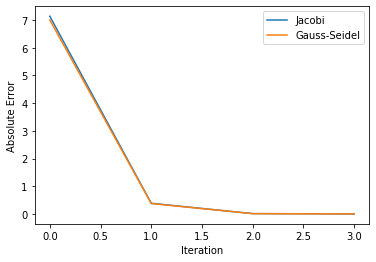


Tolerance: 1e-06
Jacobi iterations: 6
Jacobi solution: [ 3.  -2.5  7. ]
Gauss-Seidel iterations: 4
Gauss-Seidel solution: [ 3.  -2.5  7. ]


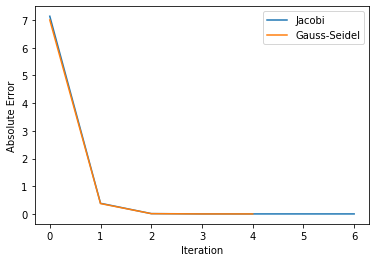


Tolerance: 1e-09
Jacobi iterations: 8
Jacobi solution: [ 3.  -2.5  7. ]
Gauss-Seidel iterations: 6
Gauss-Seidel solution: [ 3.  -2.5  7. ]


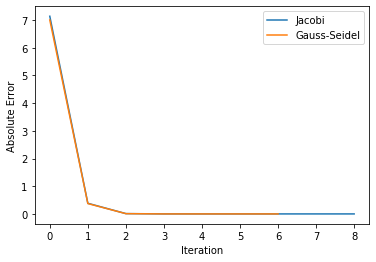

In [21]:
main()

# As the tolerance goes from (10^-3) to (10^-9), I noticed the number of interations increasing. I concluded a smaller tolerance requires more iterations because the solution needs to be more accurate. I also noticed Gauss-Seidel required less iterations. I believe this is because Gauss-Seidel uses updated values during iteration.